# Tutorial

Time to simulate $n$ steps: $\mathcal{O}(n)$ \
Memory simulation: $\mathcal{O}(n)$ \
Time analysis: $\mathcal{O}(n)$ \
Memory analysis: $\mathcal{O}(n)$ \
Time number fluorophores $n$: $\mathcal{O}(n)$ \
Check with %%time and %memit

### Naming convention
|name|meaning|
|---|---|
|SingleState|photophysical state|
|PairedState|SingleStates of donor and acceptor combined|
|TransitionType|constant attributes of photophysical transition|
|Transition|constant and variable attributes of photophysical transition|
|combined states|combinations of SingleStates depending on number of fluorophores|
|combined state transition|transitions between combined states|
|realizable|theoretically possible|
|emission|fluorescent emission|
|event|detected fluorescent emission|
|resample|frame integration time|

In [35]:
import os
import sys
path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(splitted[0]+os.sep, splitted[1], splitted[2], splitted[3])
src_path = os.path.join(user_independent, 'GitHub', 'Photoswitching')
sys.path.append(src_path)

import src.antibunching as ab
import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.statistics as st
import src.tcspc as tc
import src.transitions as tr

import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2

import warnings
def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache
        line = linecache.getline(filename, lineno)
    return f'WARNING for line: {line} {msg} \n' 
warnings.formatwarning = custom_warning_format


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Setup the fluorophore system

Fluorophore parameters
fluorophore_1.id = None
fluorophore_1.name = 'cy5'
fluorophore_1.position = array([0, 4])
fluorophore_1.parameter_set = 'set 1'
fluorophore_1.constants = Cy5(parameter_set='set 1', maximum_extinction_coefficient=250000.0, quantum_yield=0.27, fluorescence_lifetime=1e-09, isc_st_rate=830000.0, isc_ts_rate=500000.0, photobleach_t1_rate=1, iso_rate=20000000.0, biso_cross_section=1.7e-17, fret_kappa_sq=0.6666666666666666, j_homo_fret=1.55e+16, j_cis_fret=3e+16, j_triplet_fret=9000000000000000.0, j_off_fret=1000000000000000.0, dstorm_pet_t_rate_mol=100000000.0, dstorm_pet_s_rate_mol=1000000000.0, dstorm_th_el_rate=0.02)

FluorophoreSystem parameters
fluorophore_system.fluorophores = [Fluorophore(id=0, name='cy5', position=array([0, 0]), parameter_set='test', constants=Cy5(parameter_set='test', maximum_extinction_coefficient=250000.0, quantum_yield=0.27, fluorescence_lifetime=1e-09, isc_st_rate=830000.0, isc_ts_rate=5000.0, photobleach_t1_rate=0, iso_rate=20000000.0, bi

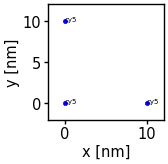

In [8]:
# Method 1: define the positions freely
fluorophore_1 = fl.Fluorophore(name='cy5', position=[0, 4], parameter_set='set 1')
fluorophore_2 = fl.Fluorophore(name='cy5', position=[4.5, 3], parameter_set='set 1')
fluorophores = [fluorophore_1, fluorophore_2]
# Method 2: collection of fluorophores in a certain shape
fluorophores = fl.construct_fluorophores(name='cy5', distance=10, count=3, shape='square', parameter_set='test')

# a Fluorophore has the following attributes
print('Fluorophore attributes')
print(f'{fluorophore_1.id = }\n{fluorophore_1.name = }\n{fluorophore_1.position = }\n' +
      f'{fluorophore_1.parameter_set = }\n{fluorophore_1.constants = }\n')

# FluorophoreSystem only takes the collection of fluorophores as parameter
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

# a FluorophoreSystem has the following attributes
print('FluorophoreSystem attributes')
print(f'{fluorophore_system.fluorophores = }\n{fluorophore_system.distances = }\n' +
      f'{fluorophore_system.count = }')

fluorophore_system.plot(scale=0.5, quadratic=True);

### Setup a transition

In [9]:
# each Transition involves some single or paired (energy transfer) photophysical states
s0 = tr.SingleState.S0
s0_s1 = tr.PairedState.S0_S1

print(f'{s0 = }\n{s0.value = }\n{s0_s1 = }\n{s0_s1.single_state_values = }\n' +
      f'{s0_s1.acceptor = }\n{s0_s1.donor = }\n')

# each Transition is of a certain TransitionType
type = tr.TransitionType.EXCITATION

# The attributes of TransitionType are
print('TransitionType attributes')
print(f'{type.abbreviation = }\n{type.initial_state = }\n{type.final_state = }\n' +
      f'{type.photon = }\n')

transition = tr.Transition(transition_type=type, rate=1e6, distance=None)

# The attributes of Transition are
print('Transition attributes')
print(f'{transition.id = }\n{transition.transition_type = }\n'+
      f'{transition.abbreviation = }\n{transition.initial_state = }\n'+
      f'{transition.final_state = }\n{transition.rate = }\n'+
      f'{transition.photon = }\n{transition.energy_transfer = }\n'+
      f'{transition.distance = }\n')


s0 = <SingleState.S0: 0>
s0.value = 0
s0_s1 = <PairedState.S0_S1: [<SingleState.S0: 0>, <SingleState.S1: 1>]>
s0_s1.single_state_values = (0, 1)
s0_s1.acceptor = <SingleState.S1: 1>
s0_s1.donor = <SingleState.S0: 0>

TransitionType parameters
type.abbreviation = 'EXC'
type.initial_state = <SingleState.S0: 0>
type.final_state = <SingleState.S1: 1>
type.photon = False

Transition parameters
transition.id = None
transition.transition_type = <TransitionType.EXCITATION: TransitionAttributes(abbreviation='EXC', initial_state=<SingleState.S0: 0>, final_state=<SingleState.S1: 1>, photon=False)>
transition.abbreviation = 'EXC'
transition.initial_state = <SingleState.S0: 0>
transition.final_state = <SingleState.S1: 1>
transition.rate = 1000000.0
transition.photon = False
transition.energy_transfer = False
transition.distance = None



### Setup the transition set

WARNING for line: transition_set_1 = tr.TransitionSet(transitions, fluorophore_system)
 HOMO_FRET distance(s) [11.0, 5.0] do not correspond to the fluorophore distance(s). 
WARNING for line: transition_set_1 = tr.TransitionSet(transitions, fluorophore_system)
 HOMO_FRET does not include the fluorophore distance(s) [10.0, 14.142]. 



 TransitionSet parameters
transition_set_3.transitions = [Transition(id=0, transition_type=<TransitionType.EXCITATION: TransitionAttributes(abbreviation='EXC', initial_state=<SingleState.S0: 0>, final_state=<SingleState.S1: 1>, photon=False)>, abbreviation='EXC', initial_state=<SingleState.S0: 0>, final_state=<SingleState.S1: 1>, rate=5000000.0, photon=False, energy_transfer=False, distance=None), Transition(id=1, transition_type=<TransitionType.FLUORESCENT_EMISSION: TransitionAttributes(abbreviation='FLU', initial_state=<SingleState.S1: 1>, final_state=<SingleState.S0: 0>, photon=True)>, abbreviation='FLU', initial_state=<SingleState.S1: 1>, final_state=<SingleState.S0: 0>, rate=270000000.0, photon=True, energy_transfer=False, distance=None), Transition(id=2, transition_type=<TransitionType.INTERSYSTEM_CROSSING_ST: TransitionAttributes(abbreviation='ISCST', initial_state=<SingleState.S1: 1>, final_state=<SingleState.T1: 3>, photon=False)>, abbreviation='ISCST', initial_state=<SingleS

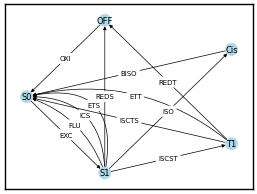

In [10]:
# Method 1: define the transitions freely
transition_1 = tr.Transition(tr.TransitionType.EXCITATION, rate=1e6, distance=None)
transition_2 = tr.Transition(tr.TransitionType.FLUORESCENT_EMISSION, rate=1e9, distance=None)
transition_3 = tr.Transition(tr.TransitionType.HOMO_FRET, rate=4e6, distance=5)
transition_4 = tr.Transition(tr.TransitionType.HOMO_FRET, rate=3e5, distance=11)
transitions = [transition_1, transition_2, transition_3, transition_4]

# TransitionSet takes transitions and FluorophoreSystem as parameters
# Note the warnings this set produces
transition_set_1 = tr.TransitionSet(transitions, fluorophore_system)

# Method 2: load a transition set, if available
transitions = fluorophore_system.load_transitions(irradiance=2.5, wavelength=640,
                                                  bleaching=True, energy_transfer=True,
                                                  dstorm=True, reducing_agent='mea',
                                                  concentration=140, ph=8)
transition_set_2 = tr.TransitionSet(transitions, fluorophore_system)

# remove transitions
# HFRET will be removed, no matter the distance
# only OFRET of distance 10.0 will be removed
transition_set_3 = transition_set_2.filter_by_abbreviation(
    remove_list=['HFRET', 'OFRET(10.0)', 'OFRET(14.1)', 'CFRET', 'STA'])

# adjust rates
transition_set_3 = transition_set_3.adjust_rates(change_dict={'EXC': 5e6})

# if everything is set, finalize the set
transition_set_2.finalize()
transition_set_3.finalize()

# for statistics and approximations it may be needed to reduce the TransitionSet
# this gets rid of absorbing states and transitions
# if energy transfers are not available to the system, reduce will assume only 1 fluorophore
transition_set_3_reduced = transition_set_3.reduce()

# The attributes of TransitionSet are
print('\n TransitionSet attributes')
print(f'{transition_set_3.transitions = }\n\n{transition_set_3.transition_df = }\n\n'+
      f'{transition_set_3.single_states = }\n\n{transition_set_3.fluorophore_system = }\n\n'+
      f'{transition_set_3.combined_state_transitions_df = }\n\n' +
      f'{transition_set_3.transition_matrix = }\n\n{transition_set_3.row_sums = }\n')

transition_set_3.plot(graph_type='shell', colors=None, scale=0.5);

### Predict some statistics of the Markov chain

Prediction parameters
prediction.transitions = <src.transitions.TransitionSet object at 0x0000029D79664640>

prediction.lifetime_distributions = array([<scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000029D09754D30>,
      dtype=object)

prediction.transition_time_distributions = array([<scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000029D09754D30>,
      dtype=object)

prediction.mean_lifetimes = array([2.00000000e-07, 9.95722603e-10, 2.30108729e-06, 7.30310977e-06,
       5.00000000e+01])

prediction.mean_transition_times = array([2.00000000e-07, 9.95722603e-10, 9.95722603e-10, 2.30108729e-06,
       9.95722603e-10, 7.30310977e-06, 9.95722603e-10, 2.30108729e-06,
       9.95722603e-10, 2.30108729e-06, 9.95722603e-10, 5.00000000e+01])

prediction.stationary_distribution_states = array([4.94866765e-01, 4.94866765e-01, 4.08982519e-04, 9.85500046e-03,
       2.51850009e-06])

prediction.stationary_distribution_transitions = array([0.4948667645

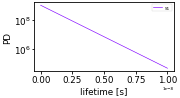

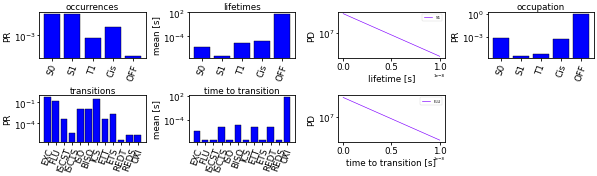

In [37]:
# this TransitionSet raises an error, because only two fluorophores can be modeled
# if energy transfers are possible
# prediction = st.Prediction(transition_set_2)
# note: lifetime distributions and occupation statistics are not available

# this TransitionSet raises an error, because it contains an absorbing state
# prediction = st.Prediction(transition_set)

# this TransitionSet works, it is reduced (no absorbing states) and contains no energy transfers
prediction = st.Prediction(transition_set_3_reduced)

# the attributes of Prediction are
print('Prediction attributes')
print(f'{prediction.transitions = }\n\n{prediction.lifetime_distributions = }\n\n' +
      f'{prediction.transition_time_distributions = }\n\n' +
      f'{prediction.mean_lifetimes = }\n\n{prediction.mean_transition_times = }\n\n' +
      f'{prediction.stationary_distribution_states = }\n\n' +
      f'{prediction.stationary_distribution_transitions = }\n\n' +
      f'{prediction.state_occupations = }')

# either plot a specific output
prediction.plot(mode='lifetime_distributions', x=np.linspace(0, 1e-8, 100), 
                include=[1], scale=0.3)
# or all plots at once
prediction.plot_all(x_lifetimes=np.linspace(0, 1e-8, 100), include_lifetimes=[1],
                    x_transitions=np.linspace(0, 1e-8, 100), include_transitions=[1],
                    scale=0.3);

### Simulation

In [52]:
# this TransitionSet raises an error, because it hasn't been finalized yet
# simulation_1 = si.Simulation(transition_set_1)
# this line solves the issue:
# transition_set_1.finalize()
# simulation_1 = si.Simulation(transition_set_1)

# basic simulation run for a given number of steps (size)
simulation_2 = si.Simulation(transition_set_2)
simulation_2.run(start_at=None, size=1e6, end_time=None, seed=3, use_memmap=None)

# simulate until it reaches given end_time
simulation_3 = si.Simulation(transition_set_3)
simulation_3.run(start_at=(0, 0, 1), size=1e6, end_time=1e-4, seed=3, use_memmap=None)

# if a lot of steps have to be carried out, the arrays may become too large for RAM
# in that case, use memory maps store on drive
# simulation_4 = si.Simulation(transition_set_3_reduced)
# simulation_4.run(start_at=None, size=1e6, end_time=None, seed=3, 
#                  use_memmap=r'C:\Users\ebert\Desktop\memory maps tests')

# the attributes of Simulation are
print('Simulation attributes')
print(f'{simulation_2.transitions = }\n\n{simulation_2.time_series = }\n\n' +
      f'{simulation_2.transition_series = }\n\n{simulation_2.state_series = }\n\n' +
      f'{simulation_2.memmap_path = }')

# alternatively, one can approximate a run:
simulation_approx = simulation_3.approximate(prediction=prediction, 
                                             strategy='individual', size=1e5, seed=3)

Simulation attributes
simulation_2.transitions = <src.transitions.TransitionSet object at 0x0000029D719BE650>

simulation_2.time_series = array([0.00000000e+00, 1.12683281e-07, 1.12830098e-07, ...,
       3.90800901e-02, 3.90800920e-02, 3.90801507e-02])

simulation_2.transition_series = array([  2, 460,   1, ...,  55, 505,  56], dtype=uint32)

simulation_2.state_series = array([[0, 1, 0, ..., 5, 5, 5],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 1, 0, 0]], dtype=int8)

simulation_2.memmap_path = None


### Simulation (GPU)

In [34]:
import src.simulation_GPU as sigpu

sigpu.list_devices()

pytorch device count: 1
pytorch device: 0
cupy device count: 1
cupy device: 0


### Statistics of the simulation
The analysis follows these rules:
- time to transitions of energy transfers are collected only from the donor's point of view
- time to transition of e.g., fluorescence, does not differentiate whether energy transfer was also an option or not
- one occurrence resembles the transition of the donor and the acceptor
- state lifetimes and occurrences do not differentiate whether energy transfer was involved or not \
\
Note: energy transfer has an impact on true fluorescence lifetime only if the acceptors are truly available. If the potential acceptor is in a non-accepting state, the energy transfer is not available. If multiple fluorophores are potential acceptors, all of their respective rates are taken into account. Depending on the photophysical system, energy transfers may only have a marginal impact on the mean fluorescence lifetime.

Analysis attributes
analysis.simulation = <src.simulation.Simulation object at 0x0000029D0E4E77C0>

analysis.transitions = <src.transitions.TransitionSet object at 0x0000029D719BE650>

analysis.lifetime_distributions = [array([1.12683281e-07, 1.08923119e-07, 5.63799975e-07, ...,
       8.13235559e-08, 1.87122429e-09, 1.10724507e-07]), array([1.46816531e-10, 2.04408532e-10, 2.74849310e-10, ...,
       1.53175778e-10, 4.32642533e-10, 1.96860617e-09]), array([4.87737110e-07, 1.02112881e-06, 4.32984985e-06, 2.80873480e-06,
       5.84268093e-07, 3.38225411e-06, 5.58435889e-06, 1.67647539e-06,
       6.01551845e-07, 1.33619927e-06, 4.80985596e-06, 9.38412171e-08,
       1.56880247e-06, 3.16441493e-06, 1.96157428e-06, 3.78789474e-06,
       8.59692703e-07, 2.13363900e-06, 1.90471701e-06, 6.29003681e-06,
       2.21055866e-06, 4.71460468e-07, 9.04695847e-06, 2.66648114e-07,
       3.61191876e-06, 7.50503801e-07, 1.06241088e-06, 2.80322720e-06,
       9.11105030e-07, 3.99649593e-07, 2.75792667

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([[<Axes: title={'center': 'occurrences'}, ylabel='PR'>,
        <Axes: title={'center': 'lifetimes'}, ylabel='mean [s]'>,
        <Axes: xlabel='lifetime [s]', ylabel='PD'>,
        <Axes: title={'center': 'occupation'}, ylabel='PR'>],
       [<Axes: title={'center': 'transitions'}, ylabel='PR'>,
        <Axes: title={'center': 'time to transition'}, ylabel='mean [s]'>,
        <Axes: xlabel='time to transition [s]', ylabel='PD'>, <Axes: >]],
      dtype=object)

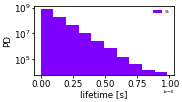

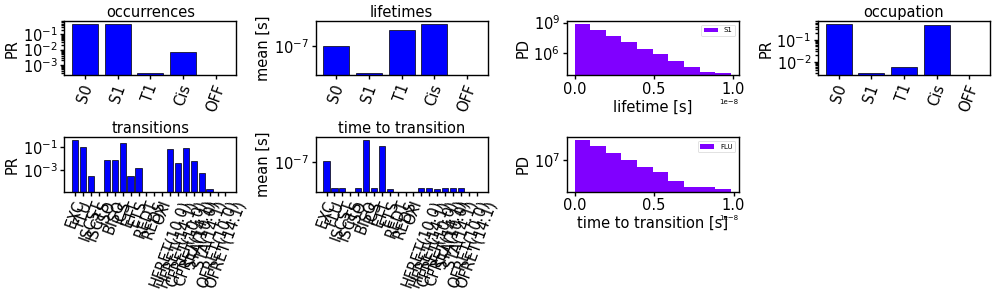

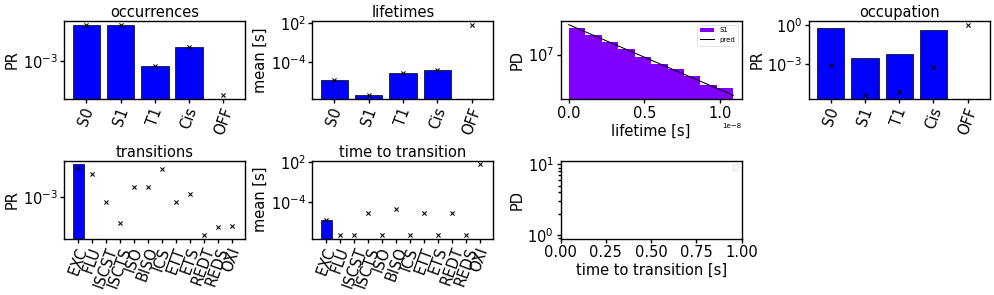

In [53]:
# Analysis can be carried out on all types of simulation data
analysis = st.Analysis(simulation=simulation_2)

# the attributes of Analysis are
print('Analysis attributes')
print(f'{analysis.simulation = }\n\n' +
      f'{analysis.transitions = }\n\n{analysis.lifetime_distributions = }\n\n' +
      f'{analysis.transition_time_distributions = }\n\n' +
      f'{analysis.mean_lifetimes = }\n\n{analysis.mean_transition_times = }\n\n' +
      f'{analysis.state_occurrences = }\n\n' +
      f'{analysis.transition_occurrences = }\n\n' +
      f'{analysis.state_occupations = }\n\n{analysis.energy_transfer = }')

# either plot a specific output
analysis.plot(mode='lifetime_distributions', include=[1], scale=0.3)

# or all plots at once
analysis.plot_all(include_lifetimes=[1], include_transitions=[1], scale=0.5)

# if prediction shall be incooperated, it should match the system of analysis
# this prediction is of a system without energy transfers, whereas 
# the analysis is of a system with energy transfers, hence an error is raised
# analysis.plot_all(prediction=prediction)
analysis_3 = st.Analysis(simulation=simulation_3)
analysis_3.plot_all(prediction=prediction, include_lifetimes=[1], 
                    include_transitions=[1], scale=0.5)


### Antibunching

### Emissions

Emissions attributes
emissions.simulation = <src.simulation.Simulation object at 0x0000029D0E4E77C0>

emissions.emission_indices = array([     9,     11,     24, ..., 999976, 999978, 999984], dtype=int64)

emissions.event_indices = array([    45,     86,    339, ..., 999662, 999739, 999966], dtype=int64)

emissions.event_time_points = array([1.24760791e-06, 1.97210892e-06, 8.70203729e-06, ...,
       3.90635845e-02, 3.90685271e-02, 3.90788742e-02])

emissions.event_time_series = 0.000    12299.0
0.005    11984.0
0.010    12537.0
0.015    12239.0
0.020    13089.0
0.025    12655.0
0.030    12016.0
0.035    10049.0
dtype: float64

analysis.transition_occurrences = array([4.60067e-01, 9.76160e-02, 3.13000e-04, 0.00000e+00, 7.15600e-03,
       7.15500e-03, 2.55818e-01, 3.13000e-04, 1.58400e-03, 0.00000e+00,
       0.00000e+00, 0.00000e+00, 6.83460e-02, 4.05300e-03, 9.05760e-02,
       6.45300e-03, 5.30000e-04, 2.00000e-05, 0.00000e+00, 0.00000e+00])


array([[<Axes: title={'center': 'cum. events'}, xlabel='time [s]', ylabel='%'>]],
      dtype=object)

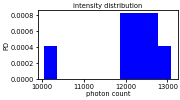

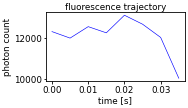

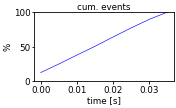

In [54]:
# Emissions can be carried out on all types of simulation data
emissions = em.Emissions(simulation=simulation_2, photon_collection_rate=0.1, 
                         resample='5ms', emccd_gain=10, seed=100)

# the attributes of Emissions are
print('Emissions attributes')
print(f'{emissions.simulation = }\n\n' +
      f'{emissions.emission_indices = }\n\n' +
      f'{emissions.event_indices = }\n\n' +
      f'{emissions.event_time_points = }\n\n' +
      f'{emissions.event_time_series = }\n\n' +
      f'{analysis.transition_occurrences = }')

# plot the intensity histogram
emissions.plot(mode='histogram', scale=0.3)

# add noise to the frames intensities
emissions.add_noise(mean=10, std=1)

# plot the fluorescence time trajectory
emissions.plot(mode='time_series', scale=0.3)

# plot the cumulative events
emissions.plot(mode='cum_events', scale=0.3)

# to save the time_series and time_points
# emissions.save(path='', name_extension='test')

# to load time_series and time_points
# emissions.load(path='', name_extension='test')



### FCS

In [ ]:
fcs = fcs.FCS(emissions)
fcs.autocorrelate_time_points(exp_min=-10, exp_max=-1)
fcs.plot()

### Blinking
An ON-period is a number of consecutive frames where each frame contains a minimum amount of emissions ($>$ threshold). An OFF-period is a number of consecutive frames where each frame contains a maximum amount of emissions ($\le$ threshold).
Each ON-period is followed by an OFF-period and vice versa.

In [ ]:
blinks = bl.Blinking(emissions)
blinks.plot(mode='off_histogram')

### TCSPC

In [ ]:
tcspc = tc.TCSPC(transition_set_2)
tcspc.run(size=1e5, seed=100)
tcspc.get_observed_lifetimes()
tcspc.plot()
tcspc.predict(accuracy=10, size=1e3)
tcspc.plot(mode='prediction')